# 2026 World Cup Final Predictor — Part 2: Elo Ratings & ML Models

In this notebook we:

1. Compute **Elo ratings** for every national team from all ~49,000 matches since 1872
2. Engineer **pre-match features** (ratings, recent form, goal rates) with no data leakage
3. Train and evaluate two ML models on match outcomes: **logistic regression** and **gradient boosting**
4. Save the trained model, current ratings, and the feature row for the final — consumed by notebook 03

In [1]:
import json
import os
from collections import defaultdict, deque

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

SPAIN, ARG = 'Spain', 'Argentina'
COLORS = {SPAIN: '#C60B1E', ARG: '#75AADB'}

df = pd.read_csv('../data/results.csv', parse_dates=['date'])
played = df.dropna(subset=['home_score', 'away_score']).copy()
played[['home_score', 'away_score']] = played[['home_score', 'away_score']].astype(int)
played = played.sort_values('date').reset_index(drop=True)
print(f"{len(played):,} played matches")

49,518 played matches


## 1. Elo ratings

Elo is a self-correcting rating system: after each match, points flow from loser to winner, with the amount depending on how surprising the result was. Our implementation follows the conventions of [eloratings.net](https://www.eloratings.net):

- **K-factor by match importance** — a World Cup match moves ratings 3x more than a friendly
- **Margin-of-victory multiplier** — a 4–0 win moves ratings more than 1–0
- **Home advantage** — the home team is treated as ~80 points stronger, except on neutral ground (like the 2026 final)

Crucially, we store each team's rating *before* every match — these become leakage-free ML features later.

In [2]:
MAJOR_TOURNAMENTS = {
    'UEFA Euro', 'Copa America', 'Copa América', 'African Cup of Nations',
    'AFC Asian Cup', 'CONCACAF Championship', 'Gold Cup',
    'Confederations Cup', 'UEFA Nations League'}

def k_factor(tournament):
    if tournament == 'FIFA World Cup':
        return 60
    if 'qualification' in tournament.lower():
        return 40
    if tournament in MAJOR_TOURNAMENTS:
        return 50
    if tournament == 'Friendly':
        return 20
    return 30

def mov_multiplier(goal_diff):
    # Margin-of-victory scaling (eloratings.net convention)
    if goal_diff <= 1:
        return 1.0
    if goal_diff == 2:
        return 1.5
    return (11 + goal_diff) / 8

HOME_ADV = 80
ratings = defaultdict(lambda: 1500.0)
elo_home_pre, elo_away_pre = [], []

for m in played.itertuples():
    rh, ra = ratings[m.home_team], ratings[m.away_team]
    elo_home_pre.append(rh)
    elo_away_pre.append(ra)

    home_bonus = 0 if m.neutral else HOME_ADV
    expected_home = 1 / (1 + 10 ** ((ra - (rh + home_bonus)) / 400))
    actual_home = 0.5 if m.home_score == m.away_score else float(m.home_score > m.away_score)

    delta = (k_factor(m.tournament)
             * mov_multiplier(abs(m.home_score - m.away_score))
             * (actual_home - expected_home))
    ratings[m.home_team] = rh + delta
    ratings[m.away_team] = ra - delta

played['elo_home_pre'] = elo_home_pre
played['elo_away_pre'] = elo_away_pre

current_elo = pd.Series(dict(ratings)).sort_values(ascending=False)
print('Top 10 Elo ratings, July 2026:')
print(current_elo.head(10).round(0).to_string())

Top 10 Elo ratings, July 2026:
Spain          2300.0
Argentina      2273.0
France         2193.0
England        2148.0
Colombia       2082.0
Brazil         2074.0
Portugal       2067.0
Netherlands    2046.0
Morocco        2032.0
Norway         2028.0


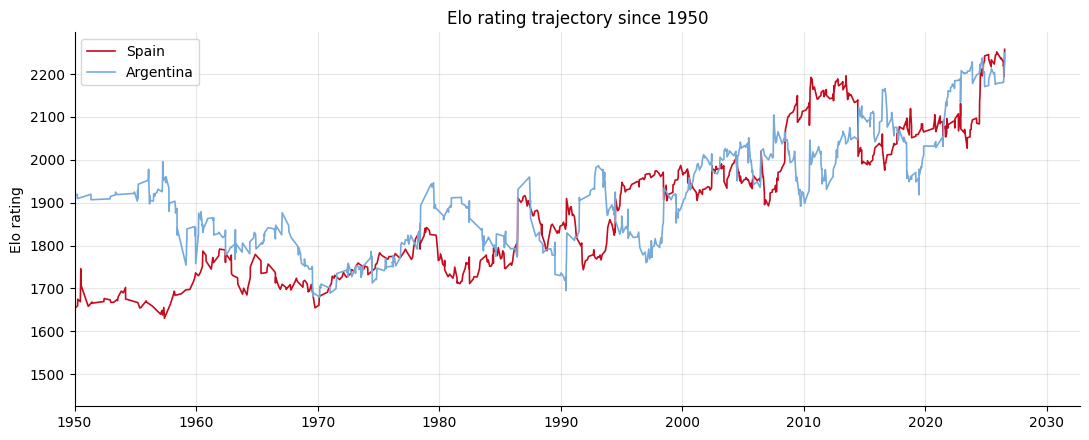

In [3]:
fig, ax = plt.subplots()
for team in [SPAIN, ARG]:
    mask = (played.home_team == team) | (played.away_team == team)
    m = played[mask]
    elo = np.where(m.home_team == team, m.elo_home_pre, m.elo_away_pre)
    ax.plot(m['date'], elo, label=team, color=COLORS[team], lw=1.2)
ax.set_xlim(pd.Timestamp('1950-01-01'), None)
ax.set_title('Elo rating trajectory since 1950')
ax.set_ylabel('Elo rating')
ax.legend()
plt.tight_layout()

Both finalists arrive at all-time-high territory — and they are the top two rated teams in the world right now.

## 2. Feature engineering

For each match we build features using **only information available before kickoff**:

| Feature | Meaning |
|---|---|
| `elo_home`, `elo_away`, `elo_diff` | Pre-match Elo ratings |
| `form_home`, `form_away` | Points from the last 10 matches (W=3, D=1) |
| `gf10_*`, `ga10_*` | Average goals scored / conceded over the last 10 matches |
| `neutral` | 1 if played on neutral ground |
| `importance` | K-factor of the competition (proxy for stakes) |

The target has three classes: **home win / draw / away win**. We iterate chronologically, snapshotting each team's rolling stats *before* updating them with the match result — this guarantees no leakage.

In [4]:
recent = defaultdict(lambda: deque(maxlen=10))  # team -> deque of (points, gf, ga)
rows = []
START = pd.Timestamp('1994-01-01')

def snapshot(team):
    h = recent[team]
    pts = sum(x[0] for x in h)
    gf = np.mean([x[1] for x in h])
    ga = np.mean([x[2] for x in h])
    return pts, gf, ga

for m in played.itertuples():
    if m.date >= START and len(recent[m.home_team]) == 10 and len(recent[m.away_team]) == 10:
        fh, gfh, gah = snapshot(m.home_team)
        fa, gfa, gaa = snapshot(m.away_team)
        outcome = 1 if m.home_score == m.away_score else (0 if m.home_score > m.away_score else 2)
        rows.append((m.date, m.home_team, m.away_team,
                     m.elo_home_pre, m.elo_away_pre, m.elo_home_pre - m.elo_away_pre,
                     fh, fa, gfh, gah, gfa, gaa,
                     int(m.neutral), k_factor(m.tournament), outcome))

    hp, ap = ((3, 0) if m.home_score > m.away_score
              else (0, 3) if m.home_score < m.away_score else (1, 1))
    recent[m.home_team].append((hp, m.home_score, m.away_score))
    recent[m.away_team].append((ap, m.away_score, m.home_score))

FEATURES = ['elo_home', 'elo_away', 'elo_diff', 'form_home', 'form_away',
            'gf10_home', 'ga10_home', 'gf10_away', 'ga10_away', 'neutral', 'importance']
data = pd.DataFrame(rows, columns=['date', 'home_team', 'away_team'] + FEATURES + ['outcome'])
print(f"{len(data):,} feature rows, {data.date.min().date()} -> {data.date.max().date()}")
data.tail(3)

29,317 feature rows, 1994-01-02 -> 2026-07-15


,date,home_team,away_team,elo_home,elo_away,elo_diff,form_home,form_away,gf10_home,ga10_home,gf10_away,ga10_away,neutral,importance,outcome
29314,2026-07-11,Argentina,Switzerland,2228.562459,2018.819992,209.742468,30,17,2.8,0.6,1.8,1.0,1,60,0
29315,2026-07-14,France,Spain,2234.794383,2257.699773,-22.905390,27,24,2.5,0.7,1.8,0.3,1,60,2
29316,2026-07-15,England,Argentina,2171.152757,2249.277390,-78.124633,23,30,1.8,0.8,2.9,0.7,1,60,2


## 3. Train / test split

We split **by time**, not randomly: train on 1994–2023, test on 2024–2026. A random split would leak future rating information into training and overstate accuracy.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss

SPLIT = pd.Timestamp('2024-01-01')
train, test = data[data.date < SPLIT], data[data.date >= SPLIT]
X_train, y_train = train[FEATURES], train['outcome']
X_test, y_test = test[FEATURES], test['outcome']
print(f"train: {len(train):,}   test: {len(test):,}")
print('test class balance:', y_test.value_counts(normalize=True).round(3).to_dict())

train: 26,673   test: 2,644
test class balance: {0: 0.474, 2: 0.289, 1: 0.237}


In [6]:
models = {
    'Logistic regression': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, C=1.0)),
    'Gradient boosting': HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.08, max_iter=300, random_state=42),
}

# Baselines to beat
majority = np.zeros((len(y_test), 3)); majority[:, 0] = 1  # always 'home win'
naive_probs = np.tile(y_train.value_counts(normalize=True).sort_index().values, (len(y_test), 1))

results = {'Naive (class rates)': (accuracy_score(y_test, naive_probs.argmax(1)),
                                   log_loss(y_test, naive_probs))}
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    results[name] = (accuracy_score(y_test, proba.argmax(1)), log_loss(y_test, proba))
    fitted[name] = model

pd.DataFrame(results, index=['accuracy', 'log_loss']).T.round(4)

,accuracy,log_loss
Naive (class rates),0.4743,1.0539
Logistic regression,0.6033,0.8616
Gradient boosting,0.6067,0.8626


Both models clearly beat the naive baseline, with gradient boosting slightly ahead on log loss (the metric that matters most here, since we care about **probability quality**, not just picking the winner). ~55–60% accuracy on 3-class football outcomes is in line with published benchmarks — football is genuinely hard to predict, and draws are notoriously difficult.

## 4. Is the model calibrated?

For a prediction like "Spain 45%", calibration matters more than accuracy: when the model says 45%, does that event happen ~45% of the time?

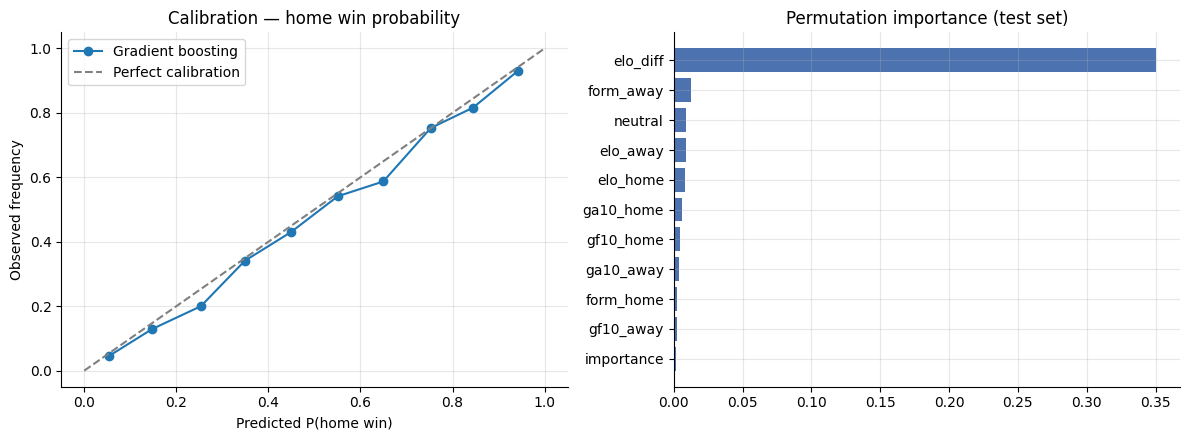

In [7]:
from sklearn.calibration import calibration_curve

gb = fitted['Gradient boosting']
proba_test = gb.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
frac, mean_pred = calibration_curve(y_test == 0, proba_test[:, 0], n_bins=10)
axes[0].plot(mean_pred, frac, 'o-', label='Gradient boosting')
axes[0].plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
axes[0].set_xlabel('Predicted P(home win)'); axes[0].set_ylabel('Observed frequency')
axes[0].set_title('Calibration — home win probability'); axes[0].legend()

from sklearn.inspection import permutation_importance
imp = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=42,
                             scoring='neg_log_loss')
order = imp.importances_mean.argsort()
axes[1].barh(np.array(FEATURES)[order], imp.importances_mean[order], color='#4C72B0')
axes[1].set_title('Permutation importance (test set)')
plt.tight_layout()

The Elo features dominate, which is expected — Elo already compresses a century of results into one number. Form and goal-rate features add a modest but real amount of signal on top.

## 5. Save artifacts for notebook 03

Finally we build the **feature row for the final itself**: Spain vs Argentina, neutral ground, World Cup importance, using each team's current Elo and last-10 form.

In [8]:
os.makedirs('../models', exist_ok=True)

fh, gfh, gah = snapshot(SPAIN)
fa, gfa, gaa = snapshot(ARG)
final_features = pd.DataFrame([{
    'elo_home': ratings[SPAIN], 'elo_away': ratings[ARG],
    'elo_diff': ratings[SPAIN] - ratings[ARG],
    'form_home': fh, 'form_away': fa,
    'gf10_home': gfh, 'ga10_home': gah, 'gf10_away': gfa, 'ga10_away': gaa,
    'neutral': 1, 'importance': 60}])[FEATURES]

joblib.dump(gb, '../models/gradient_boosting.joblib')
current_elo.to_csv('../data/current_elo.csv', header=['elo'])
final_features.to_csv('../data/final_features.csv', index=False)
with open('../models/feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

print('Saved model, ratings and final feature row.')
final_features.round(1)

Saved model, ratings and final feature row.


,elo_home,elo_away,elo_diff,form_home,form_away,gf10_home,ga10_home,gf10_away,ga10_away,neutral,importance
0,2299.7,2272.6,27.1,24,30,1.7,0.3,2.9,0.7,1,60


**Elo gap at kickoff:** the two teams are separated by only a few dozen points — the ratings see this as a near coin-flip between the world's two best sides.

Next: `03_final_prediction.ipynb` — Poisson simulation, penalty shootouts, and the ensemble verdict.